Import dependencies/libraries and the dataset

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, mean_absolute_error, mean_squared_error, r2_score
import numpy as np

file_path = "../dataset/prepared/ClassifierPreparedDataset.csv"
df = pd.read_csv(file_path)

Define the features (X) and the target (y)

In [12]:
X = df.drop(columns=["NLOS"])
y = df["NLOS"]

Split the dataset into 80% training and 20% test

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=111)

Train a Decision Tree classifier and make the predictons

In [14]:
clf = DecisionTreeClassifier(random_state=111)
clf.fit(X_train, y_train)
    
# Make predictions
y_pred = clf.predict(X_test)

Compute accuracy and classification report of the predictions against the testing data
Additionally, measure metrics such as MAE, MSE, RMSE and R^2

In [15]:
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print("Classification Report:\n", report)
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R² Score: {r2:.4f}")

Accuracy: 0.8720
Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.87      0.87      6278
           1       0.87      0.87      0.87      6322

    accuracy                           0.87     12600
   macro avg       0.87      0.87      0.87     12600
weighted avg       0.87      0.87      0.87     12600

Mean Absolute Error (MAE): 0.1280
Mean Squared Error (MSE): 0.1280
Root Mean Squared Error (RMSE): 0.3578
R² Score: 0.4879


Confusion Matrix Visulisation:
Create a heatmap to visualise the confusion matrix. Shows how many instances were correctly or incorrectly classified

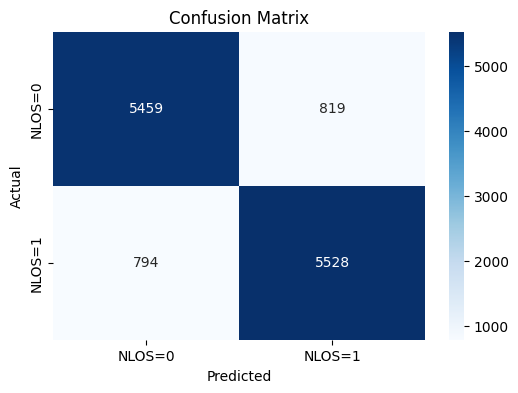

In [16]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["NLOS=0", "NLOS=1"], yticklabels=["NLOS=0", "NLOS=1"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Feature Importance Visualisation:
Shows which features are most important in the decision tree model. Higher values indicate a stronger impact on predictions.

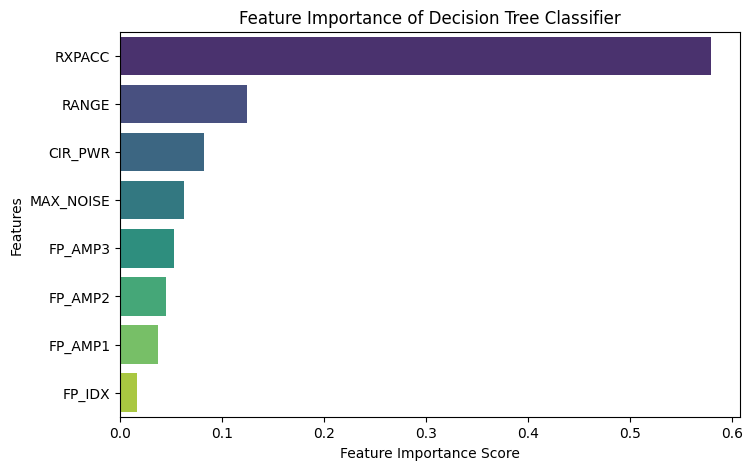

In [17]:
feature_importance = pd.Series(clf.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(8, 5))
sns.barplot(x=feature_importance, y=feature_importance.index, hue=feature_importance.index, palette="viridis", legend=False)
plt.xlabel("Feature Importance Score")
plt.ylabel("Features")
plt.title("Feature Importance of Decision Tree Classifier")
plt.show()

Visualise the decision tree (only to 2 levels of depth as example)

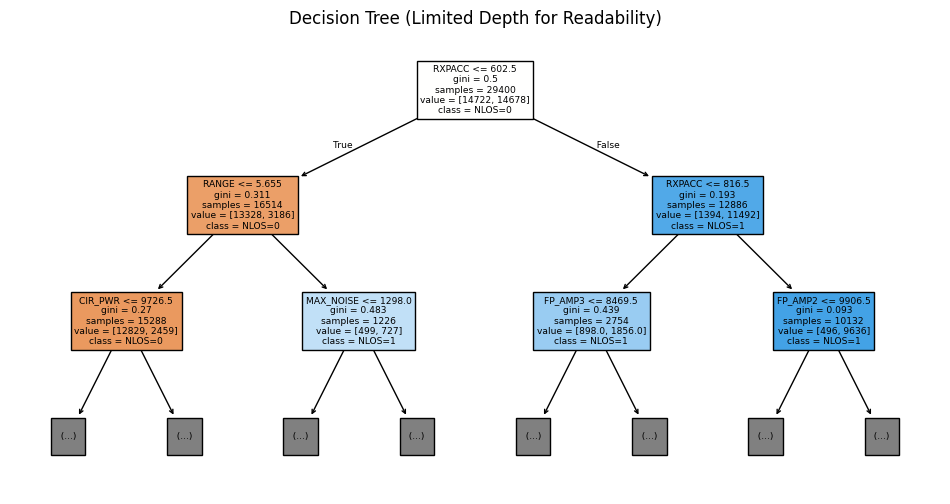

In [18]:
plt.figure(figsize=(12, 6))
plot_tree(clf, feature_names=X.columns, class_names=["NLOS=0", "NLOS=1"], filled=True, max_depth=2)
plt.title("Decision Tree (Limited Depth for Readability)")
plt.show()


--- Split: Train 80%, Test 20% ---
Accuracy: 0.8743
Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.87      0.87      4225
           1       0.87      0.88      0.87      4175

    accuracy                           0.87      8400
   macro avg       0.87      0.87      0.87      8400
weighted avg       0.87      0.87      0.87      8400

Confusion Matrix:
 [[3675  550]
 [ 506 3669]]


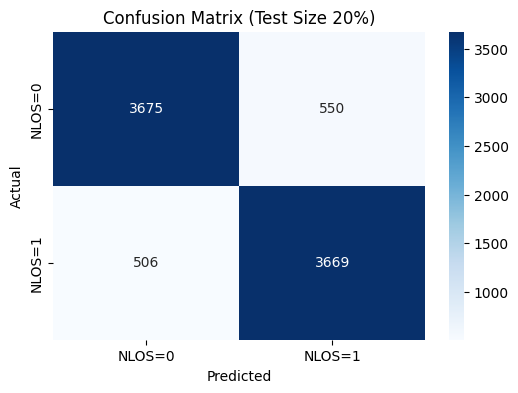


--- Split: Train 70%, Test 30% ---
Accuracy: 0.8720
Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.87      0.87      6278
           1       0.87      0.87      0.87      6322

    accuracy                           0.87     12600
   macro avg       0.87      0.87      0.87     12600
weighted avg       0.87      0.87      0.87     12600

Confusion Matrix:
 [[5459  819]
 [ 794 5528]]


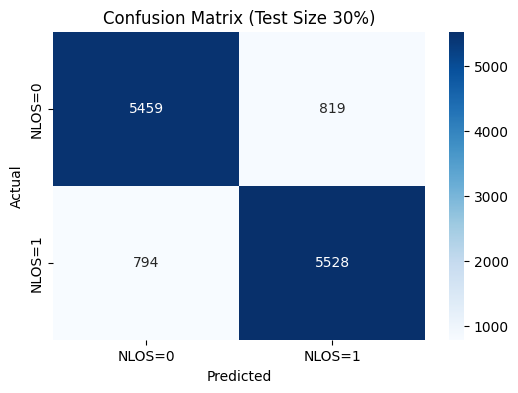

In [19]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Load the classification dataset from the prepared directory
file_path = "../dataset/prepared/ClassifierPreparedDataset.csv"
df = pd.read_csv(file_path)

# Separate features and label (target is NLOS)
X = df.drop(columns=["NLOS"])
y = df["NLOS"]

def evaluate_split(test_size, random_state=111):
    # Split data using the provided test_size
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)
    
    # Train Decision Tree Classifier
    clf = DecisionTreeClassifier(random_state=random_state)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    
    print(f"\n--- Split: Train {100 - int(test_size*100)}%, Test {int(test_size*100)}% ---")
    print(f"Accuracy: {accuracy:.4f}")
    print("Classification Report:\n", report)
    print("Confusion Matrix:\n", cm)
    
    # Plot the confusion matrix for visual inspection
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
                xticklabels=["NLOS=0", "NLOS=1"], yticklabels=["NLOS=0", "NLOS=1"])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix (Test Size {int(test_size*100)}%)")
    plt.show()

# Evaluate using an 80:20 split
evaluate_split(test_size=0.20)

# Evaluate using a 70:30 split
evaluate_split(test_size=0.30)


A 70:30 split provides a larger test set, which yields a more robust evaluation of the model’s performance. Even though 80:20 might slightly increase training data, the accuracy difference here is negligible (0.002–0.003). Therefore, 70:30 is preferable to ensure greater confidence in your model’s ability to generalize.

80:20 Split: Mean accuracy = 0.8708849206349206 Std = 0.0031418473806769792
70:30 Split: Mean accuracy = 0.8702037037037037 Std = 0.0025557267132973677

t-statistic: 0.905781677650071 p-value: 0.36879893960924093
No statistically significant difference between the splits.


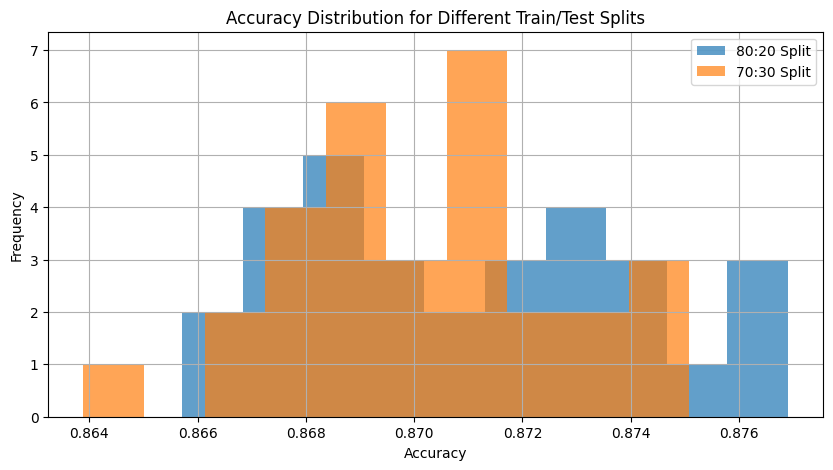

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import scipy.stats as stats

# ---------- Data Loading ----------
# GOAL:
#   Load the classification dataset from the prepared directory.
# WHY:
#   We need the dataset to perform repeated train/test splits.
# Reason:
#   To compare different split ratios (80:20 vs. 70:30) reliably.
file_path = "../dataset/prepared/ClassifierPreparedDataset.csv"
df = pd.read_csv(file_path)
X = df.drop(columns=["NLOS"])
y = df["NLOS"]

# ---------- Define Evaluation Function ----------
# GOAL:
#   Evaluate a given train/test split ratio by repeatedly splitting, training, and computing accuracy.
# WHY:
#   Repeated splits reduce variance in performance estimates and allow for statistical comparison.
# Reason:
#   This provides a distribution of accuracy scores for each split ratio.
def repeated_splits_evaluation(X, y, test_size, n_repeats=30, base_random_state=42):
    accuracies = []
    # Use different random states for each repeat
    for i in range(n_repeats):
        random_state = base_random_state + i
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, random_state=random_state
        )
        clf = DecisionTreeClassifier(random_state=42)
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        accuracies.append(acc)
    return np.array(accuracies)

# ---------- Evaluate for 80:20 and 70:30 Splits ----------
acc_80_20 = repeated_splits_evaluation(X, y, test_size=0.20, n_repeats=30)
acc_70_30 = repeated_splits_evaluation(X, y, test_size=0.30, n_repeats=30)

print("80:20 Split: Mean accuracy =", np.mean(acc_80_20), "Std =", np.std(acc_80_20))
print("70:30 Split: Mean accuracy =", np.mean(acc_70_30), "Std =", np.std(acc_70_30))

# ---------- Statistical Significance Testing ----------
# GOAL:
#   Use a t-test to compare the accuracy distributions of the two splits.
# WHY:
#   To determine whether the small observed differences are statistically significant.
t_stat, p_value = stats.ttest_ind(acc_80_20, acc_70_30)
print("\nt-statistic:", t_stat, "p-value:", p_value)
if p_value < 0.05:
    print("The difference in accuracy between the splits is statistically significant.")
else:
    print("No statistically significant difference between the splits.")

# ---------- Plot Histograms of Accuracy Distributions ----------
# GOAL:
#   Visualize the distribution of accuracy scores for both split ratios.
# WHY:
#   Histograms help visually compare variability and central tendency.
plt.figure(figsize=(10, 5))
plt.hist(acc_80_20, bins=10, alpha=0.7, label="80:20 Split")
plt.hist(acc_70_30, bins=10, alpha=0.7, label="70:30 Split")
plt.xlabel("Accuracy")
plt.ylabel("Frequency")
plt.title("Accuracy Distribution for Different Train/Test Splits")
plt.legend()
plt.grid(True)
plt.show()


Both 80:20 and 70:30 splits produce very similar mean accuracies (both around 0.87) and a p-value of about 0.37, indicating no statistically significant difference. In practical terms, you can pick 70:30 if you want a larger test set (for more robust evaluation) or 80:20 if you prefer more training data. Since the difference in performance is negligible, either split is justifiable.

Given that both splits show almost identical performance and no statistically significant difference, I recommend the 70:30 split.

Why?

It provides a larger test set, which typically yields a more robust evaluation of model performance.
The marginal benefit of slightly more training data (80:20) does not appear to materially improve accuracy here, so having more test samples for a better generalization check is preferable.

Decision Tree Classifier (Dropping 'FP_AMP3', Retaining 'RANGE'):
Accuracy: 0.8679
Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.86      0.87      6278
           1       0.87      0.87      0.87      6322

    accuracy                           0.87     12600
   macro avg       0.87      0.87      0.87     12600
weighted avg       0.87      0.87      0.87     12600

Confusion Matrix:
 [[5418  860]
 [ 804 5518]]


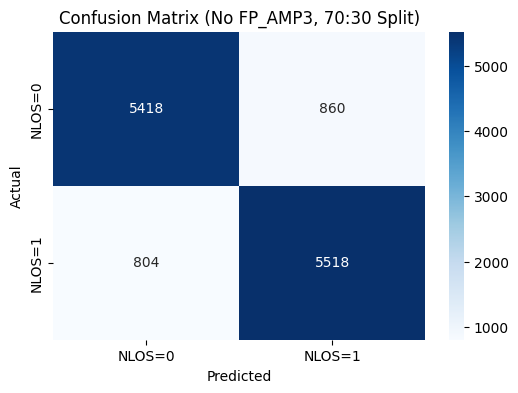

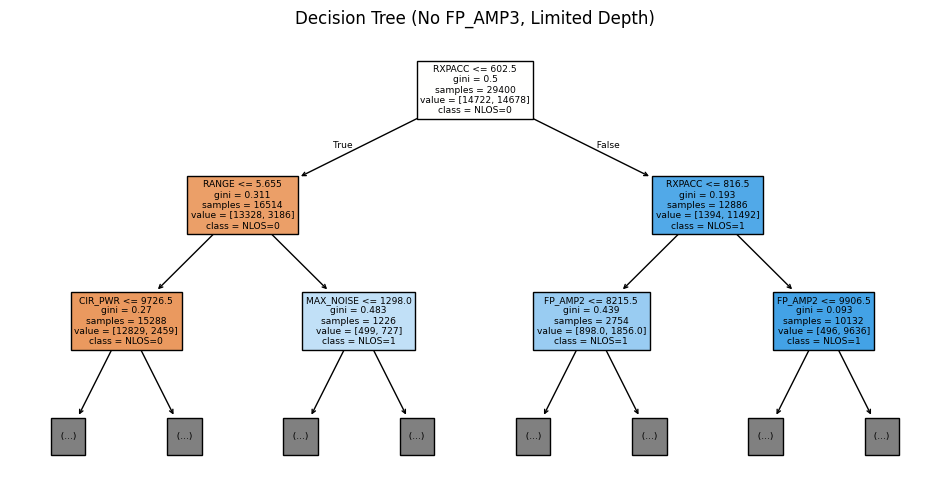

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np

# -----------------------------
# Cell: Decision Tree Classifier dropping 'FP_AMP3'
# -----------------------------
# GOAL:
#   Retain 'RANGE' but remove 'FP_AMP3' from the feature set, then compare performance
#   to see if dropping FP_AMP3 (potentially correlated with FP_AMP2) helps or hurts classification.
#
# WHY:
#   If FP_AMP3 is highly correlated with FP_AMP2, it might not add much new information,
#   and removing it could simplify the model or potentially improve generalization.
#
# Reason:
#   Checking performance with/without FP_AMP3 reveals whether it's essential for classification.

# Load the classification dataset
file_path = "../dataset/prepared/ClassifierPreparedDataset.csv"
df = pd.read_csv(file_path)

# Define the feature set by dropping 'NLOS' (label) and 'FP_AMP3' (suspected redundancy)
# while keeping 'RANGE'.
features_to_drop = ["NLOS", "FP_AMP3"]
X = df.drop(columns=features_to_drop)
y = df["NLOS"]

# Split data into training (70%) and testing (30%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=111)

# Train the Decision Tree Classifier
clf = DecisionTreeClassifier(random_state=111)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

# Evaluate performance
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("Decision Tree Classifier (Dropping 'FP_AMP3', Retaining 'RANGE'):")
print(f"Accuracy: {accuracy:.4f}")
print("Classification Report:\n", report)
print("Confusion Matrix:\n", cm)

# Plot confusion matrix
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=["NLOS=0", "NLOS=1"], yticklabels=["NLOS=0", "NLOS=1"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (No FP_AMP3, 70:30 Split)")
plt.show()

# (Optional) Visualize the top-level decision tree
plt.figure(figsize=(12, 6))
plot_tree(clf, feature_names=X.columns, class_names=["NLOS=0", "NLOS=1"], filled=True, max_depth=2)
plt.title("Decision Tree (No FP_AMP3, Limited Depth)")
plt.show()


Your new accuracy is 0.8679, which is essentially unchanged from the previous 
≈
0.87
≈0.87 results. This suggests dropping FP_AMP3 does not significantly hurt (nor improve) classification performance. In other words:

No Major Performance Drop: Accuracy remains around 0.87.
Likely Redundant Feature: FP_AMP3 appears highly correlated with FP_AMP2, so removing it does not reduce the model’s predictive power.
Recommendation: You can safely exclude FP_AMP3 if you want to simplify your feature set, given there’s no accuracy loss.